# XAI — SHAP para MLP-sklearn y MLP-Keras

Calcula la importancia de características para los dos modelos MLP usando SHAP.

## Diferencia respecto a los árboles
Los MLPs no tienen `feature_importances_`, por lo que **no hay MDI**. Para SHAP se usa `KernelExplainer`, que es agnóstico al modelo pero mucho más lento que `TreeExplainer`. Por eso se trabaja con una **muestra pequeña** (100–200 filas) tanto para el background como para la explicación.

## Salidas por modelo × herramienta
- SHAP bar plot (importancia media absoluta, top-15)
- SHAP beeswarm con signo (contrafácticos, top-15)
- Tabla resumen con las top-10 features por herramienta
- Comparación SHAP ranking entre herramientas

> ⚙️ **Aviso de tiempo**: KernelExplainer es lento. Con SHAP_SAMPLE=100 y BACKGROUND=50 espera ~5-15 min por herramienta. Si va muy lento, baja SHAP_SAMPLE a 50.

In [1]:
# ============================================================
# CELDA 0 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import shap
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

shap.initjs()
print('✓ Imports OK')
print(f'  shap: {shap.__version__}')
print(f'  tf:   {tf.__version__}')

/home/miguel/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports OK
  shap: 0.49.1
  tf:   2.16.1


In [2]:
# ============================================================
# CELDA 1 — CONFIGURACIÓN
# ============================================================

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = [
    'BenignTraffic', 'DictionaryBruteForce', 'Recon',
    'Mirai', 'Spoofing', 'DoS', 'DDoS', 'Web'
]
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']
SEED = 42
TEST_SIZE = 0.2
TOP_N = 15

# KernelExplainer: cuántas filas usar como background y para explicar
BACKGROUND_SIZE = 50   # filas de referencia para KernelExplainer
SHAP_SAMPLE = 100      # filas a explicar

COLS_ELIMINAR = {
    'CIC':    ['Label', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port',
               'Timestamp', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
               'URG Flag Cnt', 'CWR Flag Count', 'ECE Flag Cnt',
               'Fwd Bytes/Bulk Avg', 'Fwd Bulk Rate Avg', 'Fwd Packet/Bulk Avg'],
    'Nemea':  ['LABEL', 'uint64 FLOW_ID', 'macaddr DST_MAC', 'macaddr SRC_MAC',
               'ipaddr SRC_IP', 'ipaddr DST_IP', 'uint16 SRC_PORT', 'uint16 DST_PORT',
               'time TIME_FIRST', 'time TIME_LAST',
               'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
               'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP'] +
              [f'time_PPI_PKT_TIMES_{i}' for i in range(30)],
    'Tstat':  ['etiqueta', 'fqdn', 'c_tls_SNI', 's_tls_SCN', 'c_npnalpn', 's_npnalpn',
               'c_tls_sesid', 'dns_rslv', 'last', 'c_first', 's_first', 'c_last', 's_last',
               'c_first_ack', 's_first_ack', 'c_last_handshakeT', 's_last_handshakeT',
               'c_appdataT', 's_appdataT', 'req_tm', 'res_tm', 's_first_abs',
               'c_ip', 's_ip', 'c_port', 's_port', 'first', 'c_first_abs'],
    'Tshark': ['category', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'start_epoch'],
}

# Mejores hiperparámetros MLP-sklearn (Optuna 20 trials)
MEJORES_MLPSK = {
    'CIC':    dict(n1=41,  n2=51, activation='tanh', alpha=1.52e-05, learning_rate_init=0.0009462),
    'Nemea':  dict(n1=78,  n2=18, activation='relu', alpha=3.98e-04, learning_rate_init=0.0005193),
    'Tstat':  dict(n1=41,  n2=51, activation='tanh', alpha=1.52e-05, learning_rate_init=0.0009462),
    'Tshark': dict(n1=45,  n2=61, activation='relu', alpha=3.98e-04, learning_rate_init=0.0082101),
}

# Mejores hiperparámetros MLP-Keras (Optuna 20 trials)
MEJORES_KERAS = {
    'CIC':    dict(n1=99, n2=13, dropout=0.0208, lr=0.003085, batch=64),
    'Nemea':  dict(n1=99, n2=13, dropout=0.0208, lr=0.003085, batch=64),
    'Tstat':  dict(n1=75, n2=9,  dropout=0.0488, lr=0.002336, batch=200),
    'Tshark': dict(n1=44, n2=33, dropout=0.0765, lr=0.008971, batch=128),
}

GUARDAR_FIGURAS = True
RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MDI')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print('✓ Configuración cargada')

✓ Configuración cargada


In [3]:
# ============================================================
# CELDA 2 — FUNCIÓN DE CARGA
# ============================================================

def cargar_herramienta(herramienta):
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if not ruta.exists():
            print(f'  ⚠ No encontrado: {ruta}')
            continue
        df_tmp = pd.read_csv(ruta, low_memory=False)
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True)

    cols_por_clase = [set(pd.read_csv(RUTA_BASE / c / f'{herramienta}.csv',
                                      nrows=0, low_memory=False).columns)
                      for c in CLASES
                      if (RUTA_BASE / c / f'{herramienta}.csv').exists()]
    cols_comunes = set.intersection(*cols_por_clase) if cols_por_clase else set(df.columns)
    df = df[[c for c in df.columns if c in cols_comunes or c == 'Label_Modelo']]

    cols_drop = [c for c in COLS_ELIMINAR.get(herramienta, []) if c in df.columns]
    df = df.drop(columns=cols_drop)

    if herramienta == 'Nemea':
        quic_cols = [c for c in df.columns if 'QUIC' in c.upper()]
        df = df.drop(columns=quic_cols)

    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    for col in X.select_dtypes(include='object').columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    ctes = [c for c in X.columns if X[c].nunique() <= 1]
    X = X.drop(columns=ctes)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    feature_names = list(X.columns)
    print(f'[{herramienta}] Shape X: {X.shape}')
    return X, y, feature_names


def plot_shap_bar(shap_values_raw, feature_names, titulo, ruta_fig=None):
    """Bar plot SHAP (|SHAP| medio). Igual que en árboles."""
    # Para KernelExplainer shap_values puede ser 3D (n_samples, n_features, n_clases)
    if isinstance(shap_values_raw, list):
        shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values_raw], axis=0)
    elif shap_values_raw.ndim == 3:
        shap_abs_mean = np.mean(np.abs(shap_values_raw), axis=2)
    else:
        shap_abs_mean = np.abs(shap_values_raw)

    fig, ax = plt.subplots(figsize=(8, 6))
    shap.summary_plot(
        shap_abs_mean, np.zeros((shap_abs_mean.shape[0], len(feature_names))),
        feature_names=feature_names,
        max_display=TOP_N,
        plot_type='bar',
        show=False
    )
    plt.title(titulo, fontsize=12)
    plt.tight_layout()
    if ruta_fig and GUARDAR_FIGURAS:
        fig.savefig(ruta_fig, dpi=150)
    plt.show()
    plt.close()

    if isinstance(shap_values_raw, list):
        shap_abs_mean2 = np.mean([np.abs(sv) for sv in shap_values_raw], axis=0)
    elif shap_values_raw.ndim == 3:
        shap_abs_mean2 = np.mean(np.abs(shap_values_raw), axis=2)
    else:
        shap_abs_mean2 = np.abs(shap_values_raw)
    return pd.Series(shap_abs_mean2.mean(axis=0), index=feature_names).nlargest(15)


print('✓ Funciones de carga y plot definidas')

✓ Funciones de carga y plot definidas



  MLP-sklearn — CIC


[CIC] Shape X: (27848, 69)
  F1 macro: 0.6502
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:11<00:00,  8.35it/s]


  tipo shap_values: <class 'numpy.ndarray'>
  array shape: (100, 69, 8)


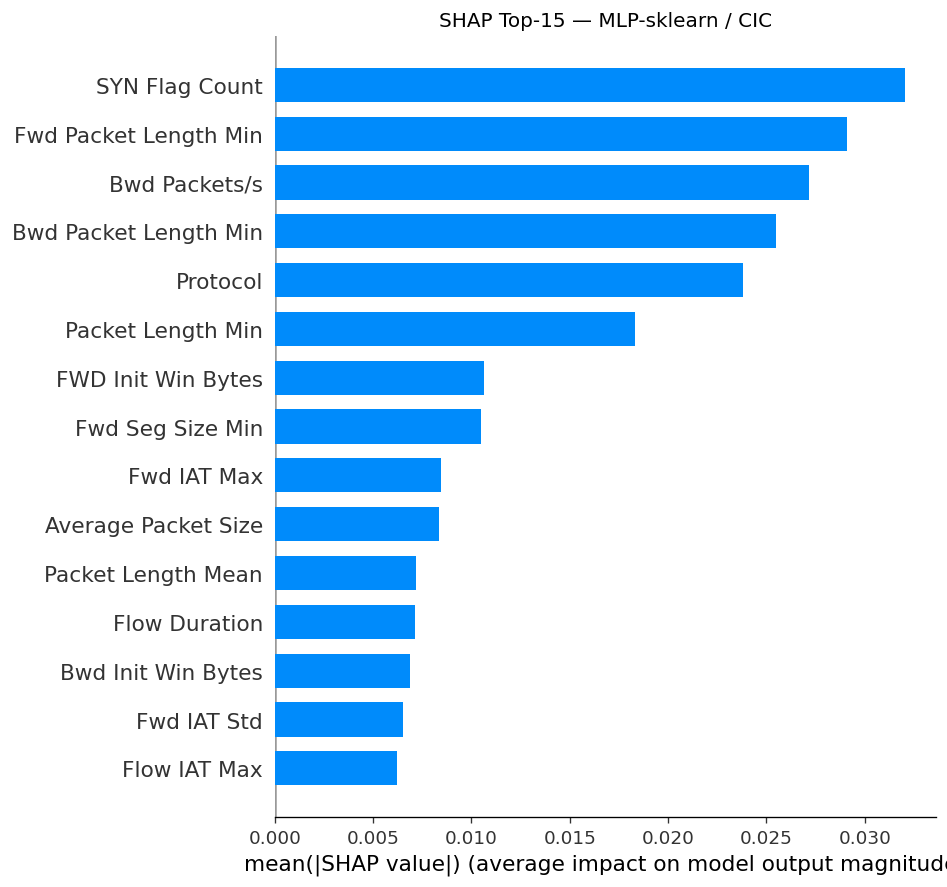


  MLP-sklearn — Nemea
[Nemea] Shape X: (27848, 148)
  F1 macro: 0.5439
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:14<00:00,  6.85it/s]


  tipo shap_values: <class 'numpy.ndarray'>
  array shape: (100, 148, 8)


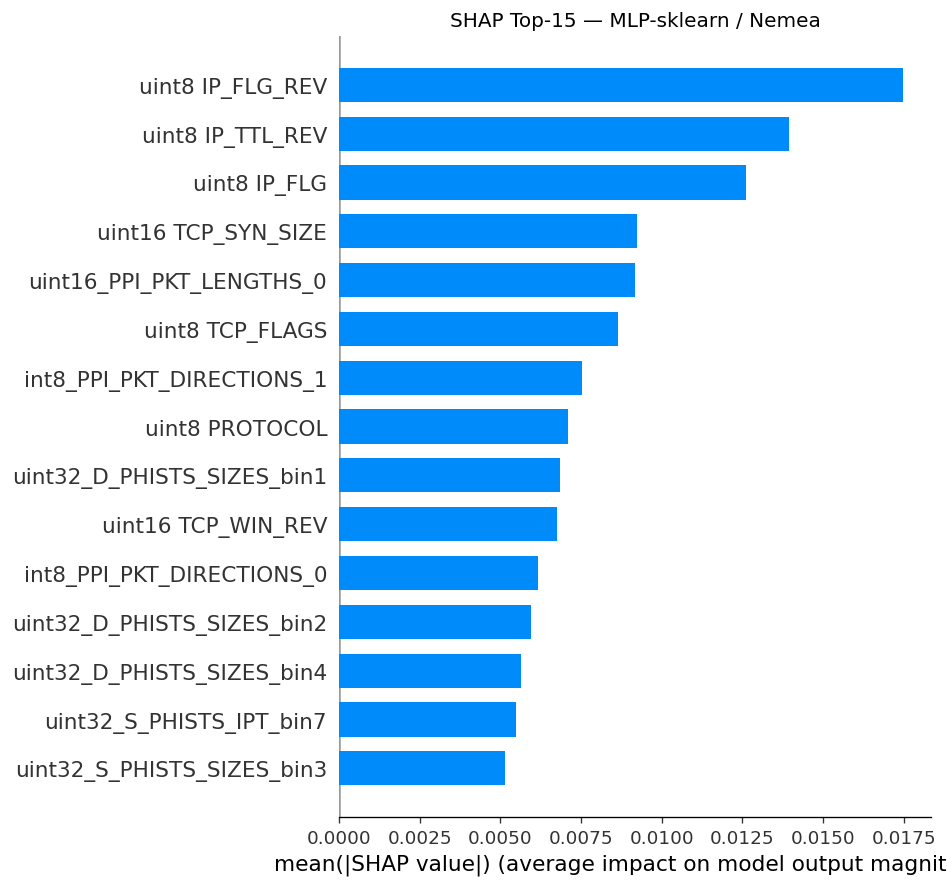


  MLP-sklearn — Tstat
[Tstat] Shape X: (27848, 96)
  F1 macro: 0.4602
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:15<00:00,  6.66it/s]


  tipo shap_values: <class 'numpy.ndarray'>
  array shape: (100, 96, 8)


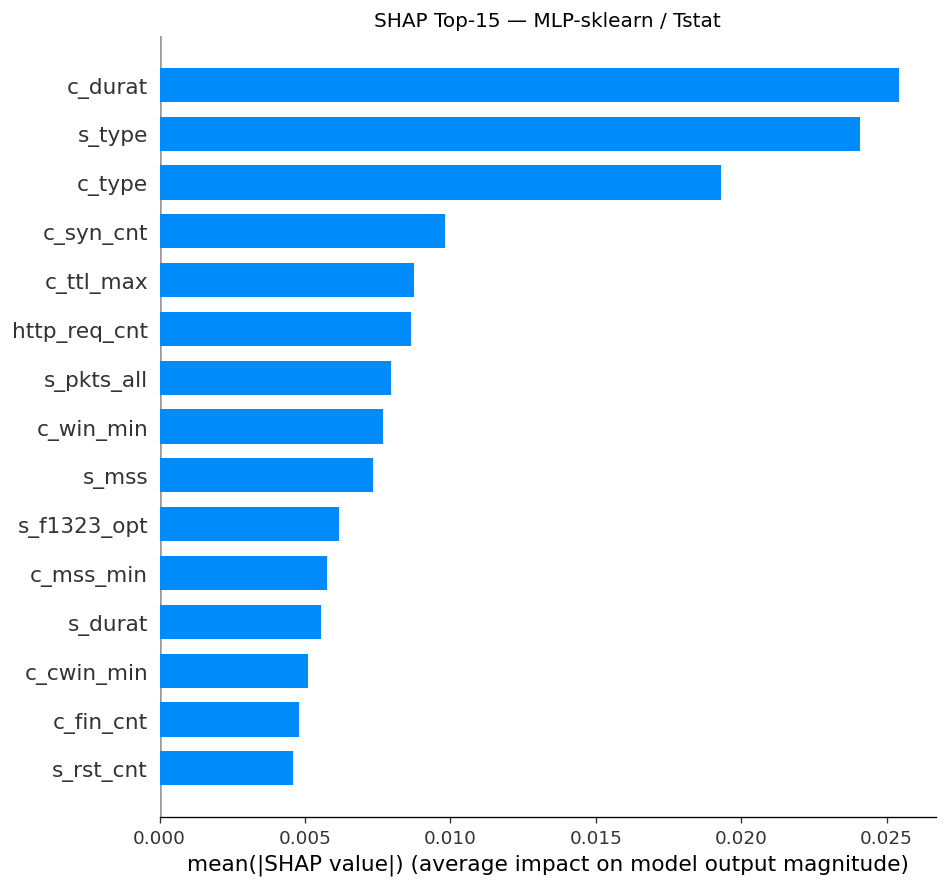


  MLP-sklearn — Tshark
[Tshark] Shape X: (27848, 50)
  F1 macro: 0.6451
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:09<00:00, 10.25it/s]


  tipo shap_values: <class 'numpy.ndarray'>
  array shape: (100, 50, 8)


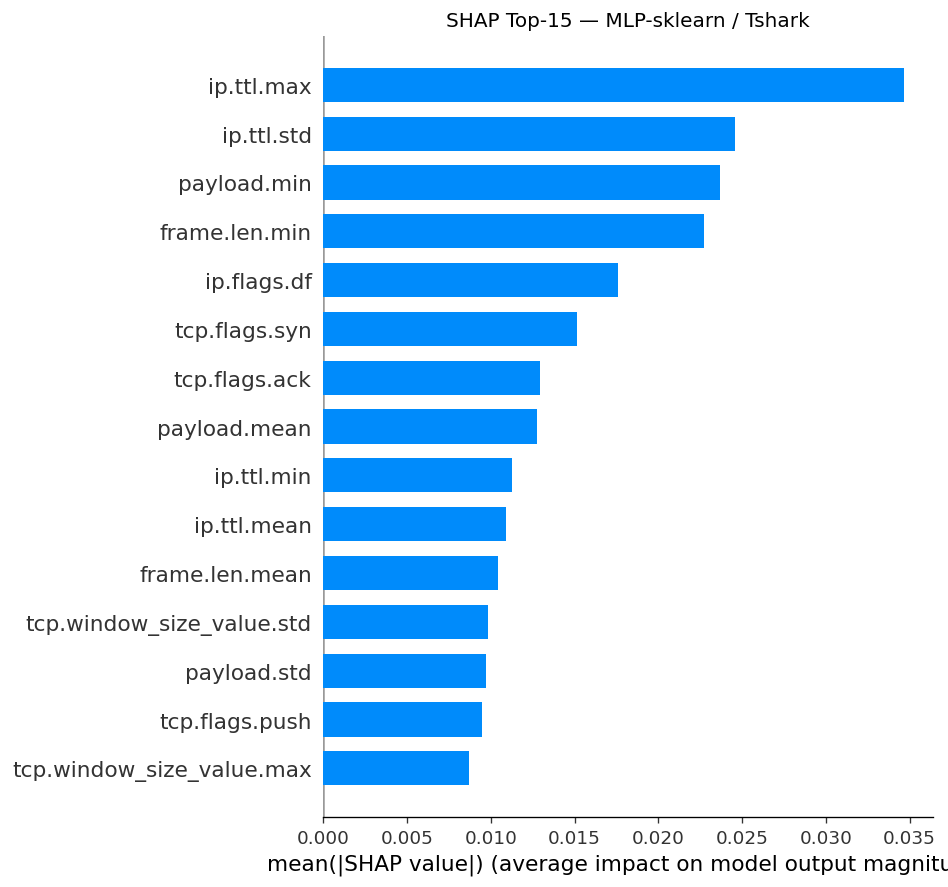


✓ MLP-sklearn completado


In [4]:
# ============================================================
# CELDA 3 — MLP SKLEARN + SHAP (KernelExplainer)
# ============================================================

resultados_mlpsk = []

for herramienta in HERRAMIENTAS:
    sep = '='*55; print(f'\n{sep}')
    print(f'  MLP-sklearn — {herramienta}')
    sep = '='*55; print(sep)

    X, y, feature_names = cargar_herramienta(herramienta)
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=TEST_SIZE, random_state=SEED, stratify=y_enc)

    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train)
    X_test_s  = sc.transform(X_test)

    hp = MEJORES_MLPSK[herramienta]
    modelo = MLPClassifier(
        hidden_layer_sizes=(hp['n1'], hp['n2']),
        activation=hp['activation'],
        alpha=hp['alpha'],
        learning_rate_init=hp['learning_rate_init'],
        solver='adam', max_iter=300, random_state=SEED
    )
    modelo.fit(X_train_s, y_train)
    f1 = f1_score(y_test, modelo.predict(X_test_s), average='macro')
    print(f'  F1 macro: {f1:.4f}')

    # KernelExplainer
    print(f'  Calculando SHAP (KernelExplainer, background={BACKGROUND_SIZE}, sample={SHAP_SAMPLE})...')
    np.random.seed(SEED)
    idx_bg = np.random.choice(len(X_train_s), BACKGROUND_SIZE, replace=False)
    background = shap.kmeans(X_train_s[idx_bg], 10)

    explainer = shap.KernelExplainer(modelo.predict_proba, background)
    X_explain = X_test_s[:SHAP_SAMPLE]
    shap_values = explainer.shap_values(X_explain, nsamples=100)
    print(f'  tipo shap_values: {type(shap_values)}')
    if isinstance(shap_values, list):
        print(f'  lista de {len(shap_values)} arrays, shape[0]: {shap_values[0].shape}')
    else:
        print(f'  array shape: {shap_values.shape}')

    shap_top = plot_shap_bar(
        shap_values, feature_names,
        f'SHAP Top-{TOP_N} — MLP-sklearn / {herramienta}',
        RUTA_FIGURAS / f'SHAP_bar_MLPsk_{herramienta}.pdf'
    )

    resultados_mlpsk.append({
        'modelo':          'MLP-sklearn',
        'herramienta':     herramienta,
        'f1':              f1,
        'shap_top':        shap_top,
        'shap_values_raw': shap_values,
        'X_shap_raw':      X_explain,
        'feature_names':   feature_names,
    })

print('\n✓ MLP-sklearn completado')


  MLP-Keras — CIC
[CIC] Shape X: (27848, 69)
  F1 macro: 0.5650
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


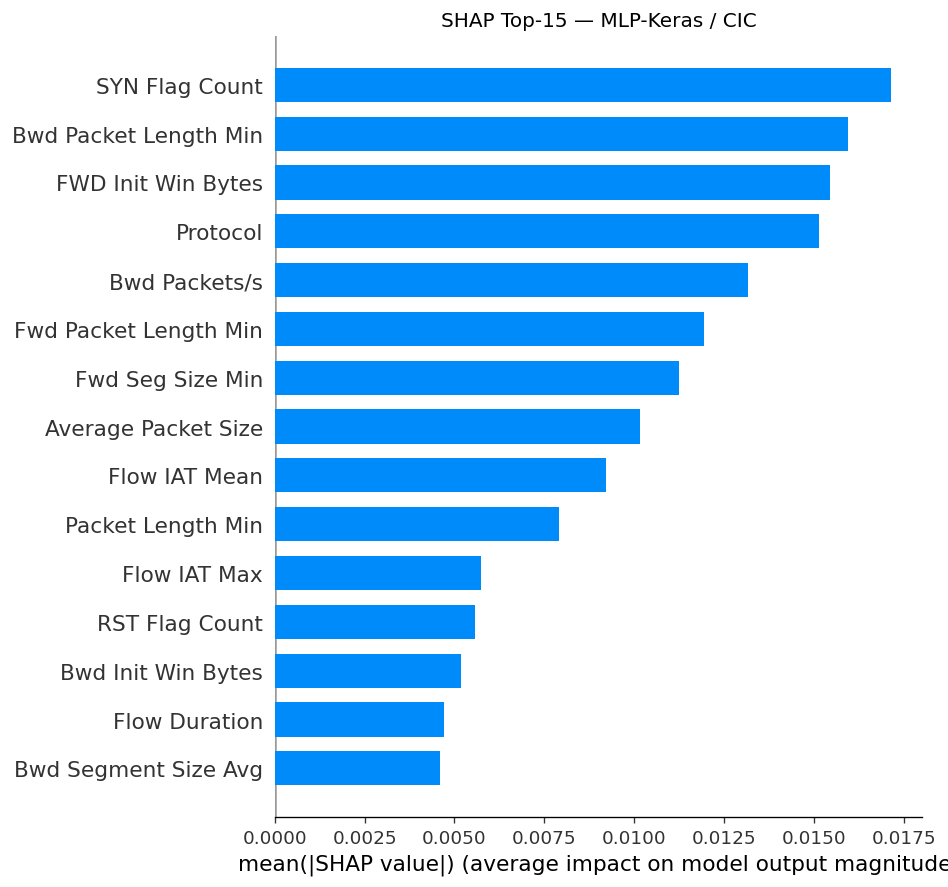


  MLP-Keras — Nemea
[Nemea] Shape X: (27848, 148)
  F1 macro: 0.5089
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


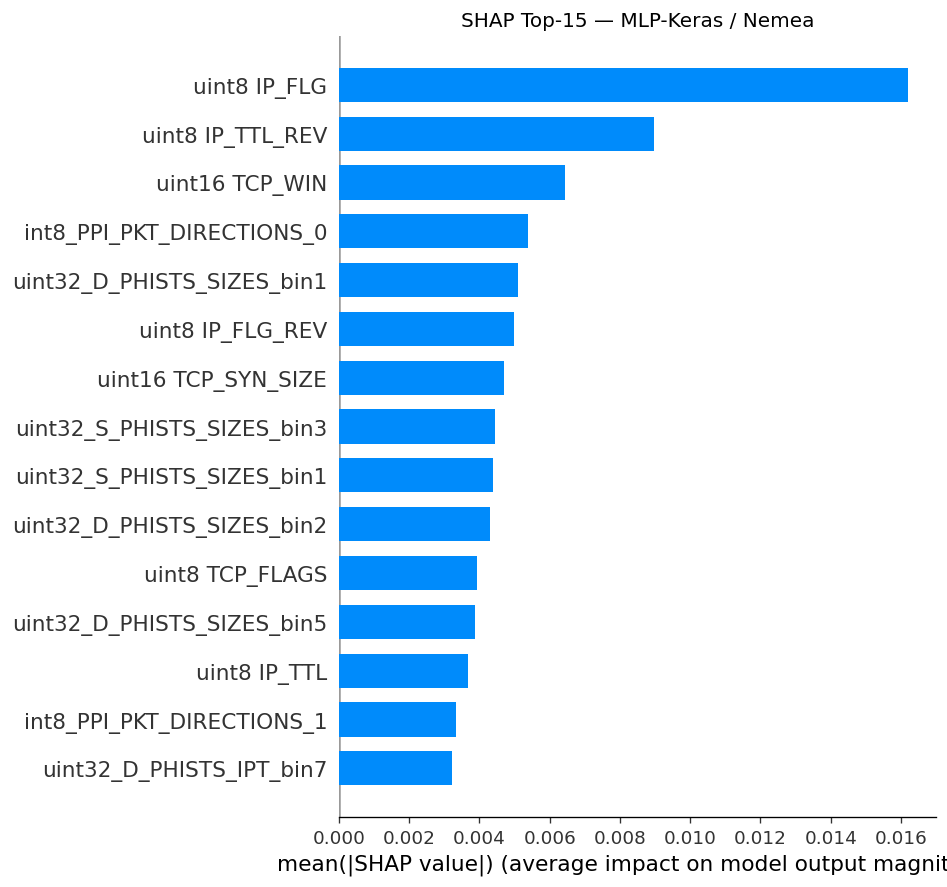


  MLP-Keras — Tstat
[Tstat] Shape X: (27848, 96)
  F1 macro: 0.4228
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:56<00:00,  1.78it/s]


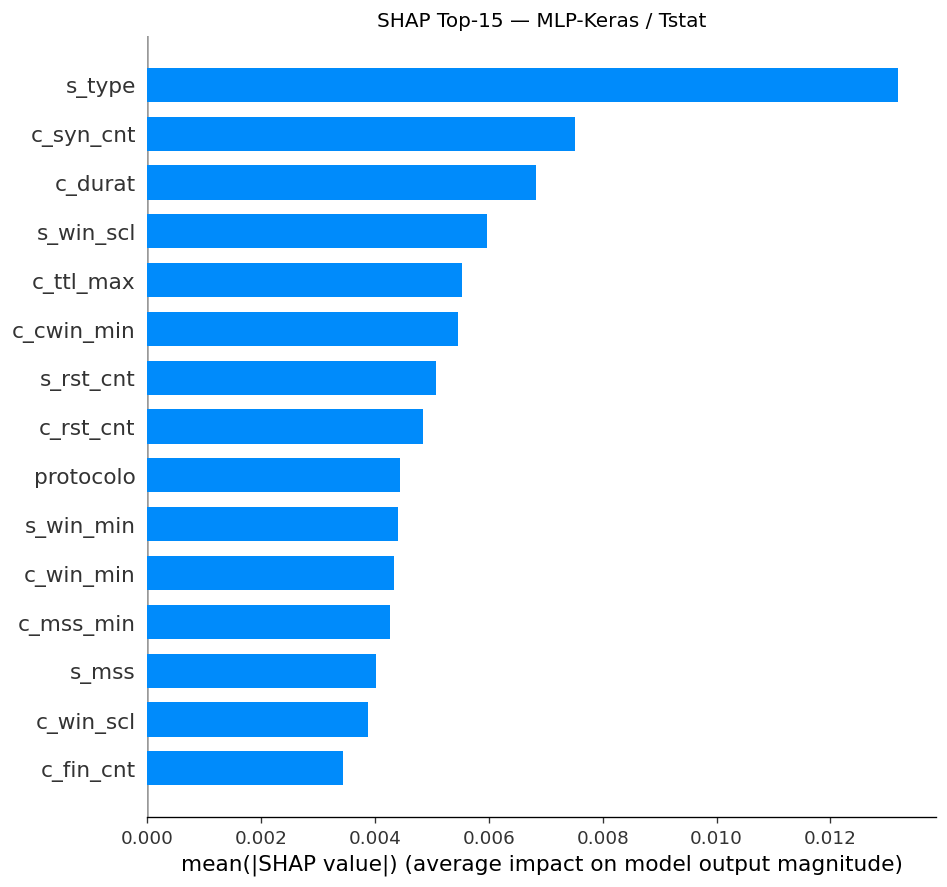


  MLP-Keras — Tshark
[Tshark] Shape X: (27848, 50)
  F1 macro: 0.5582
  Calculando SHAP (KernelExplainer, background=50, sample=100)...


100%|██████████| 100/100 [00:46<00:00,  2.13it/s]


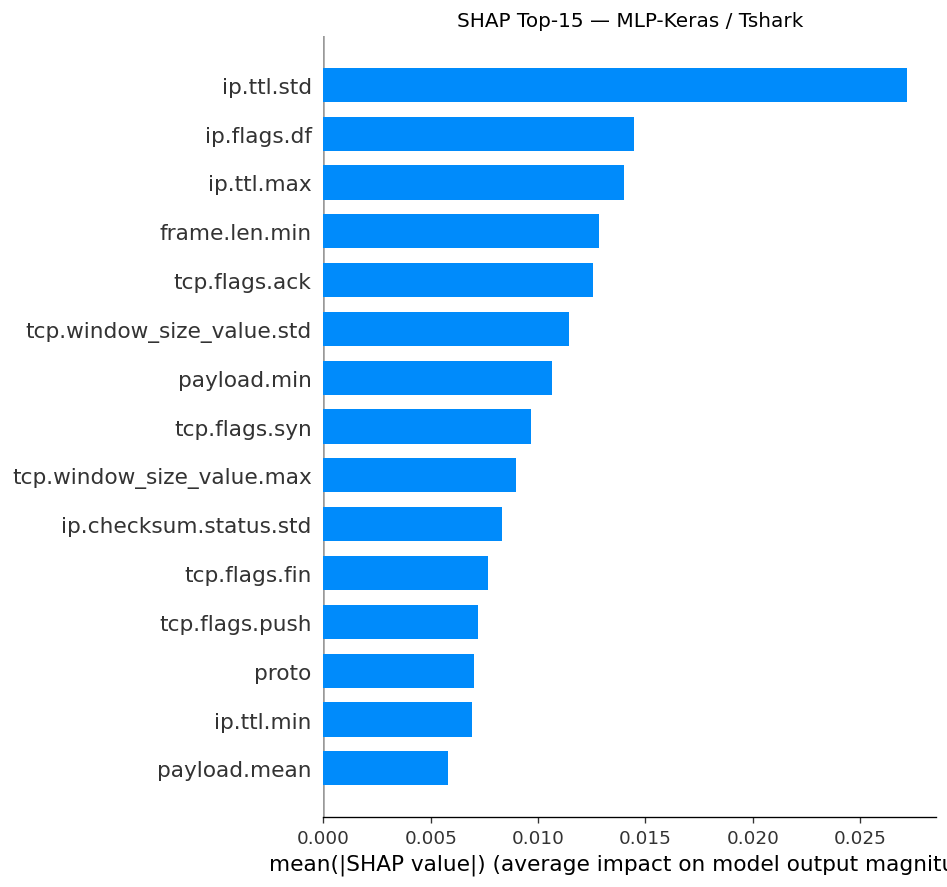


✓ MLP-Keras completado


In [5]:
# ============================================================
# CELDA 4 — MLP KERAS + SHAP (KernelExplainer)
# ============================================================

def construir_keras(n1, n2, dropout, lr, n_features, n_clases):
    model = Sequential([
        Dense(n1, activation='relu', kernel_regularizer=l2(0.001), input_shape=(n_features,)),
        Dropout(dropout),
        Dense(n2, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


resultados_keras = []

for herramienta in HERRAMIENTAS:
    sep = '='*55; print(f'\n{sep}')
    print(f'  MLP-Keras — {herramienta}')
    sep = '='*55; print(sep)

    X, y, feature_names = cargar_herramienta(herramienta)
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)
    n_clases = len(le_y.classes_)

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=TEST_SIZE, random_state=SEED, stratify=y_enc)

    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train)
    X_test_s  = sc.transform(X_test)
    y_train_oh = to_categorical(y_train, n_clases)

    hp = MEJORES_KERAS[herramienta]
    modelo = construir_keras(hp['n1'], hp['n2'], hp['dropout'], hp['lr'],
                              X_train_s.shape[1], n_clases)
    modelo.fit(X_train_s, y_train_oh,
               epochs=50, batch_size=hp['batch'], verbose=0)

    y_pred = np.argmax(modelo.predict(X_test_s, verbose=0), axis=1)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'  F1 macro: {f1:.4f}')

    print(f'  Calculando SHAP (KernelExplainer, background={BACKGROUND_SIZE}, sample={SHAP_SAMPLE})...')
    np.random.seed(SEED)
    idx_bg = np.random.choice(len(X_train_s), BACKGROUND_SIZE, replace=False)
    background = shap.kmeans(X_train_s[idx_bg], 10)

    def predict_fn(x):
        return modelo.predict(x, verbose=0)

    explainer = shap.KernelExplainer(predict_fn, background)
    X_explain = X_test_s[:SHAP_SAMPLE]
    shap_values = explainer.shap_values(X_explain, nsamples=100)

    shap_top = plot_shap_bar(
        shap_values, feature_names,
        f'SHAP Top-{TOP_N} — MLP-Keras / {herramienta}',
        RUTA_FIGURAS / f'SHAP_bar_MLPkeras_{herramienta}.pdf'
    )

    resultados_keras.append({
        'modelo':          'MLP-Keras',
        'herramienta':     herramienta,
        'f1':              f1,
        'shap_top':        shap_top,
        'shap_values_raw': shap_values,
        'X_shap_raw':      X_explain,
        'feature_names':   feature_names,
    })

print('\n✓ MLP-Keras completado')

In [6]:
# ============================================================
# CELDA 5 — TABLA RESUMEN MLP
# ============================================================

todos_mlp = resultados_mlpsk + resultados_keras

print('\n' + '='*80)
print('  RESUMEN TOP-5 SHAP — MLP-sklearn y MLP-Keras')
print('='*80)

for herramienta in HERRAMIENTAS:
    print(f'\n── {herramienta} ──')
    for res in [r for r in todos_mlp if r['herramienta'] == herramienta]:
        top15 = res['shap_top'].head(15)
        features_str = ', '.join(top15.index.tolist())
        print(f'  {res["modelo"]:15s} (F1={res["f1"]:.4f}): {features_str}')

# Exportar CSV
filas = []
for res in todos_mlp:
    for rank, (feat, val) in enumerate(res['shap_top'].items(), 1):
        filas.append({
            'Modelo': res['modelo'], 'Herramienta': res['herramienta'],
            'F1 macro': round(res['f1'], 4), 'Rank SHAP': rank,
            'Feature': feat, 'SHAP medio': round(float(val), 6)
        })

df_resumen = pd.DataFrame(filas)
ruta_csv = RUTA_FIGURAS / 'shap_resumen_mlp.csv'
df_resumen.to_csv(ruta_csv, index=False)
print(f'\n✓ Resumen guardado en {ruta_csv}')
df_resumen[df_resumen['Rank SHAP'] <= 15]


  RESUMEN TOP-5 SHAP — MLP-sklearn y MLP-Keras

── CIC ──
  MLP-sklearn     (F1=0.6502): SYN Flag Count, Fwd Packet Length Min, Bwd Packets/s, Bwd Packet Length Min, Protocol, Packet Length Min, FWD Init Win Bytes, Fwd Seg Size Min, Fwd IAT Max, Average Packet Size, Packet Length Mean, Flow Duration, Bwd Init Win Bytes, Fwd IAT Std, Flow IAT Max
  MLP-Keras       (F1=0.5650): SYN Flag Count, Bwd Packet Length Min, FWD Init Win Bytes, Protocol, Bwd Packets/s, Fwd Packet Length Min, Fwd Seg Size Min, Average Packet Size, Flow IAT Mean, Packet Length Min, Flow IAT Max, RST Flag Count, Bwd Init Win Bytes, Flow Duration, Bwd Segment Size Avg

── Nemea ──
  MLP-sklearn     (F1=0.5439): uint8 IP_FLG_REV, uint8 IP_TTL_REV, uint8 IP_FLG, uint16 TCP_SYN_SIZE, uint16_PPI_PKT_LENGTHS_0, uint8 TCP_FLAGS, int8_PPI_PKT_DIRECTIONS_1, uint8 PROTOCOL, uint32_D_PHISTS_SIZES_bin1, uint16 TCP_WIN_REV, int8_PPI_PKT_DIRECTIONS_0, uint32_D_PHISTS_SIZES_bin2, uint32_D_PHISTS_SIZES_bin4, uint32_S_PHISTS_IPT_bi

,Modelo,Herramienta,F1 macro,Rank SHAP,Feature,SHAP medio
0,MLP-sklearn,CIC,0.6502,1,SYN Flag Count,0.032018
1,MLP-sklearn,CIC,0.6502,2,Fwd Packet Length Min,0.029080
2,MLP-sklearn,CIC,0.6502,3,Bwd Packets/s,0.027154
3,MLP-sklearn,CIC,0.6502,4,Bwd Packet Length Min,0.025497
4,MLP-sklearn,CIC,0.6502,5,Protocol,0.023818
...,...,...,...,...,...,...
115,MLP-Keras,Tshark,0.5582,11,tcp.flags.fin,0.007663
116,MLP-Keras,Tshark,0.5582,12,tcp.flags.push,0.007210
117,MLP-Keras,Tshark,0.5582,13,proto,0.006994
118,MLP-Keras,Tshark,0.5582,14,ip.ttl.min,0.006927


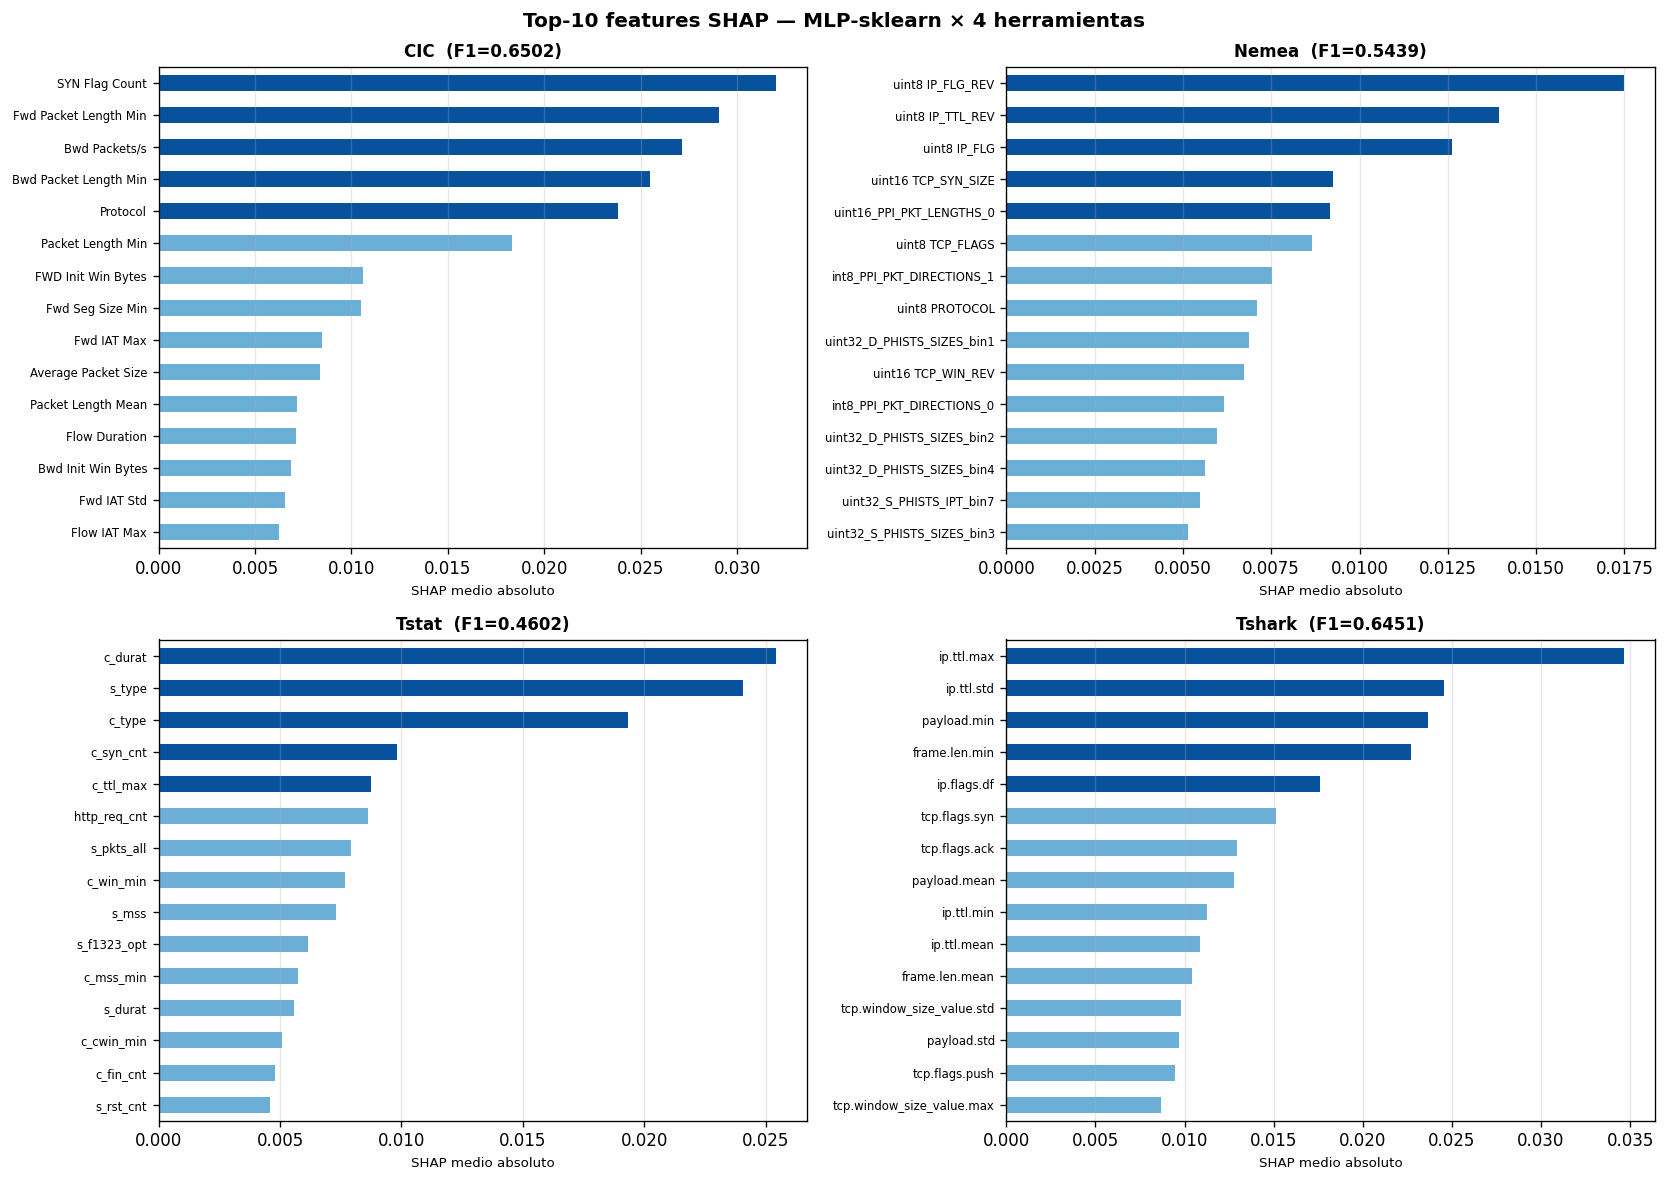

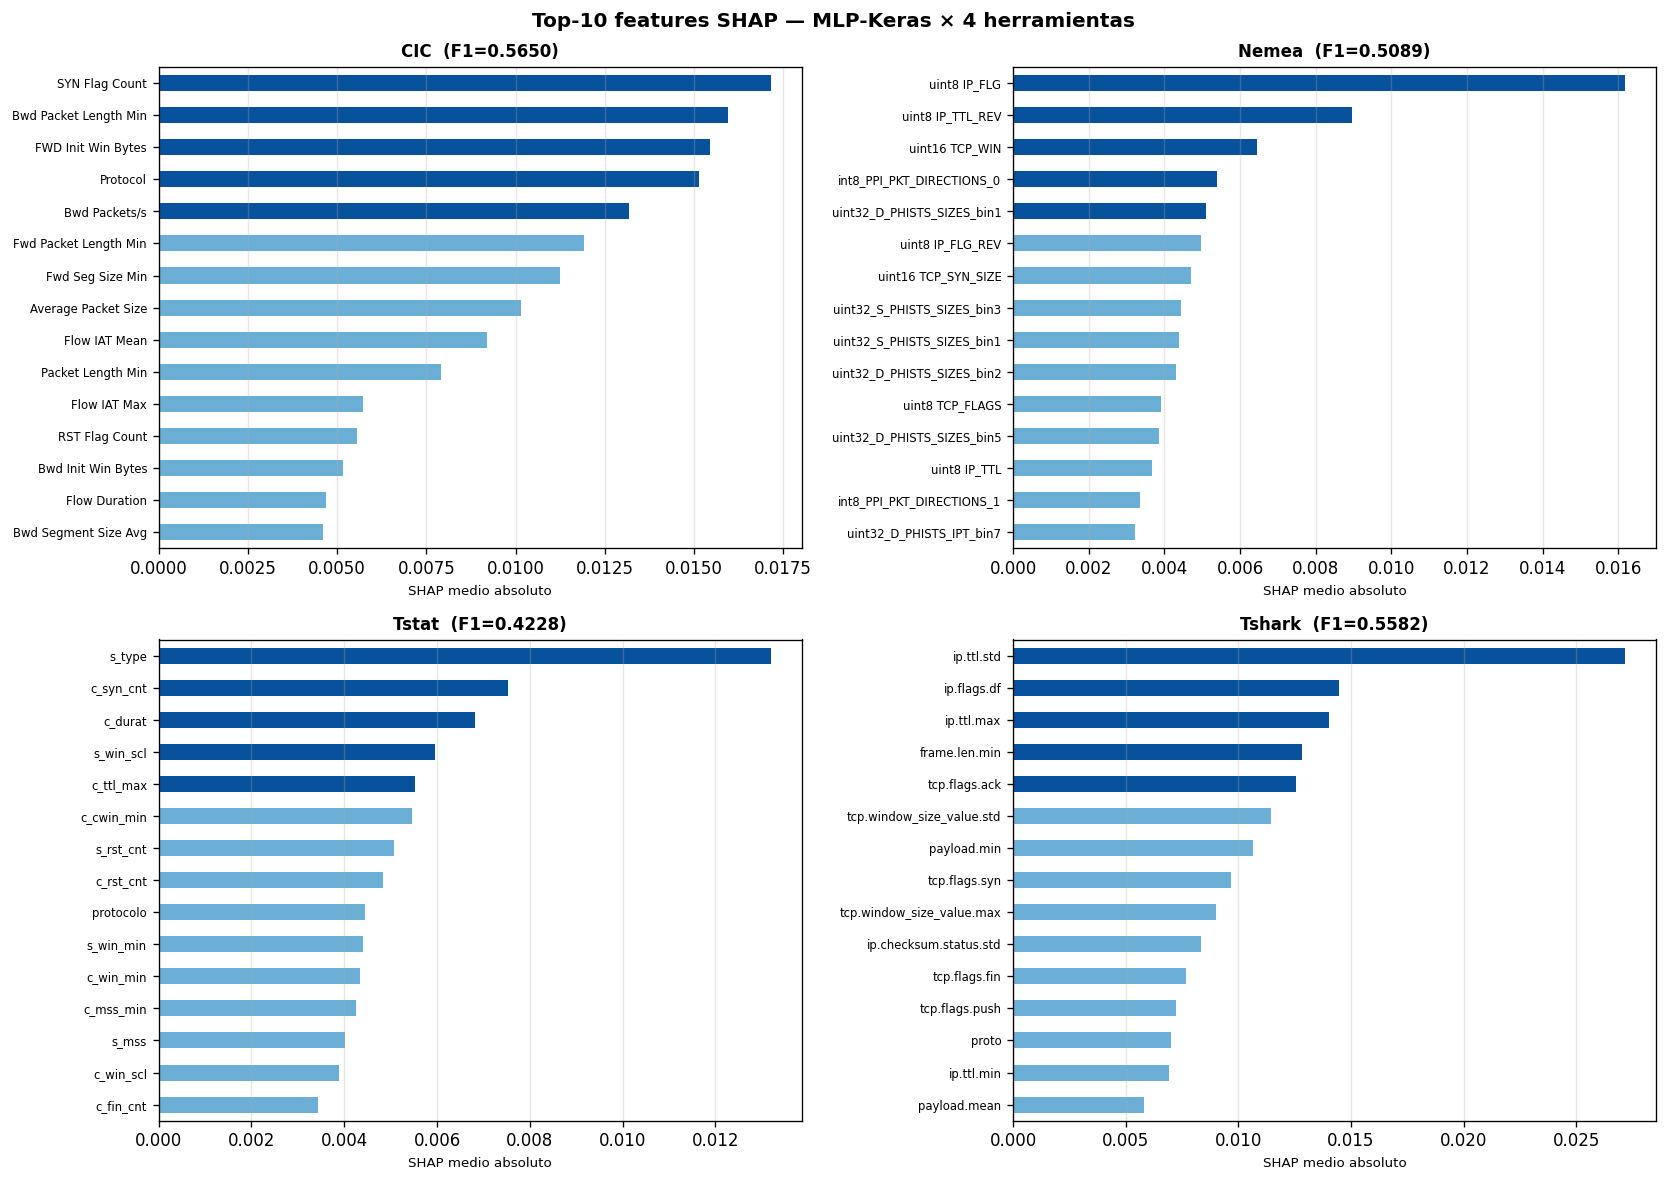

In [7]:
# ============================================================
# CELDA 6 — GRÁFICO COMPARATIVO SHAP × 4 herramientas (MLP-sklearn y MLP-Keras)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, herramienta in enumerate(HERRAMIENTAS):
    res = next(r for r in resultados_mlpsk if r['herramienta'] == herramienta)
    top10 = res['shap_top']
    ax = axes[idx]
    colores = ['#08519c' if i < 5 else '#6baed6' for i in range(len(top10))]
    top10.sort_values().plot(kind='barh', ax=ax, color=list(reversed(colores)))
    ax.set_title(f'{herramienta}  (F1={res["f1"]:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('SHAP medio absoluto', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'Top-10 features SHAP — MLP-sklearn × 4 herramientas', fontsize=12, fontweight='bold')
plt.tight_layout()
if GUARDAR_FIGURAS:
    fig.savefig(RUTA_FIGURAS / 'SHAP_comparativo_MLPsk.pdf', dpi=150)
plt.show()
plt.close()

# Mismo gráfico para Keras
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, herramienta in enumerate(HERRAMIENTAS):
    res = next(r for r in resultados_keras if r['herramienta'] == herramienta)
    top10 = res['shap_top']
    ax = axes[idx]
    colores = ['#08519c' if i < 5 else '#6baed6' for i in range(len(top10))]
    top10.sort_values().plot(kind='barh', ax=ax, color=list(reversed(colores)))
    ax.set_title(f'{herramienta}  (F1={res["f1"]:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('SHAP medio absoluto', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'Top-10 features SHAP — MLP-Keras × 4 herramientas', fontsize=12, fontweight='bold')
plt.tight_layout()
if GUARDAR_FIGURAS:
    fig.savefig(RUTA_FIGURAS / 'SHAP_comparativo_MLPkeras.pdf', dpi=150)
plt.show()
plt.close()


[CIC] Beeswarm con signo — MLP-sklearn
  Rango SHAP: [-0.0391, 0.0321]
  Features con valores negativos: 30 de 69


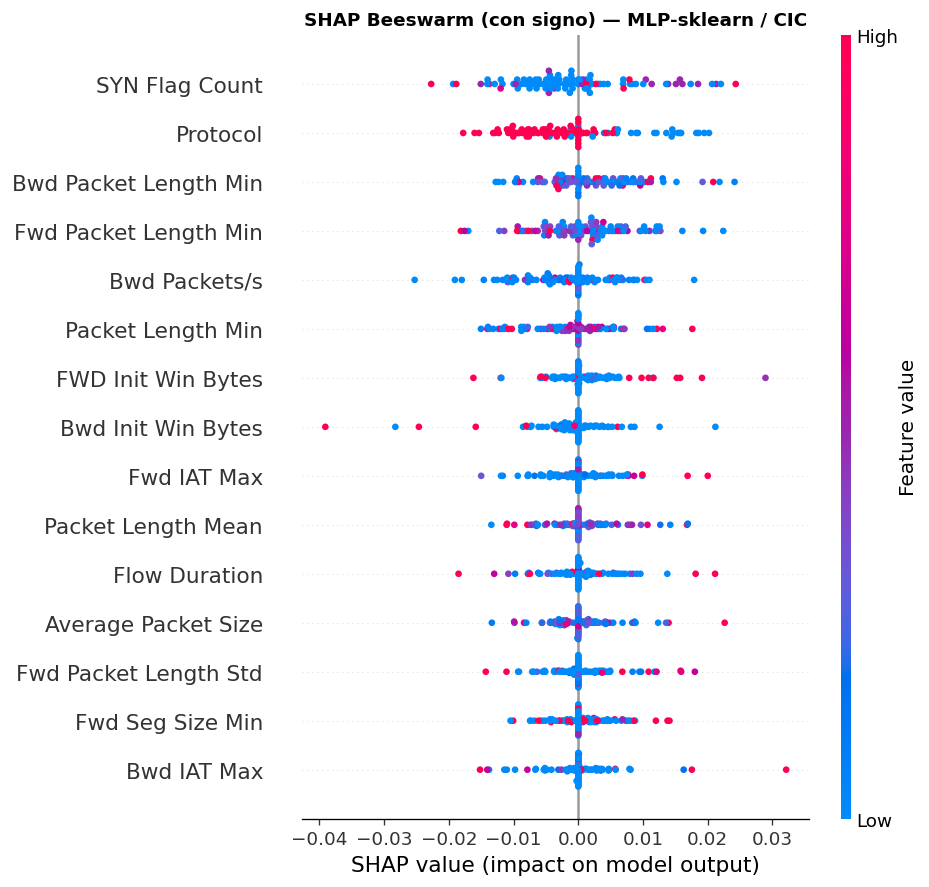

  Top contrafácticos (SHAP medio negativo):
    Bwd Packets/s                             -0.00159
    Packet Length Min                         -0.00139
    Bwd Init Win Bytes                        -0.00125
    Protocol                                  -0.00112
    FIN Flag Count                            -0.00077

[Nemea] Beeswarm con signo — MLP-sklearn
  Rango SHAP: [-0.0398, 0.0435]
  Features con valores negativos: 75 de 148


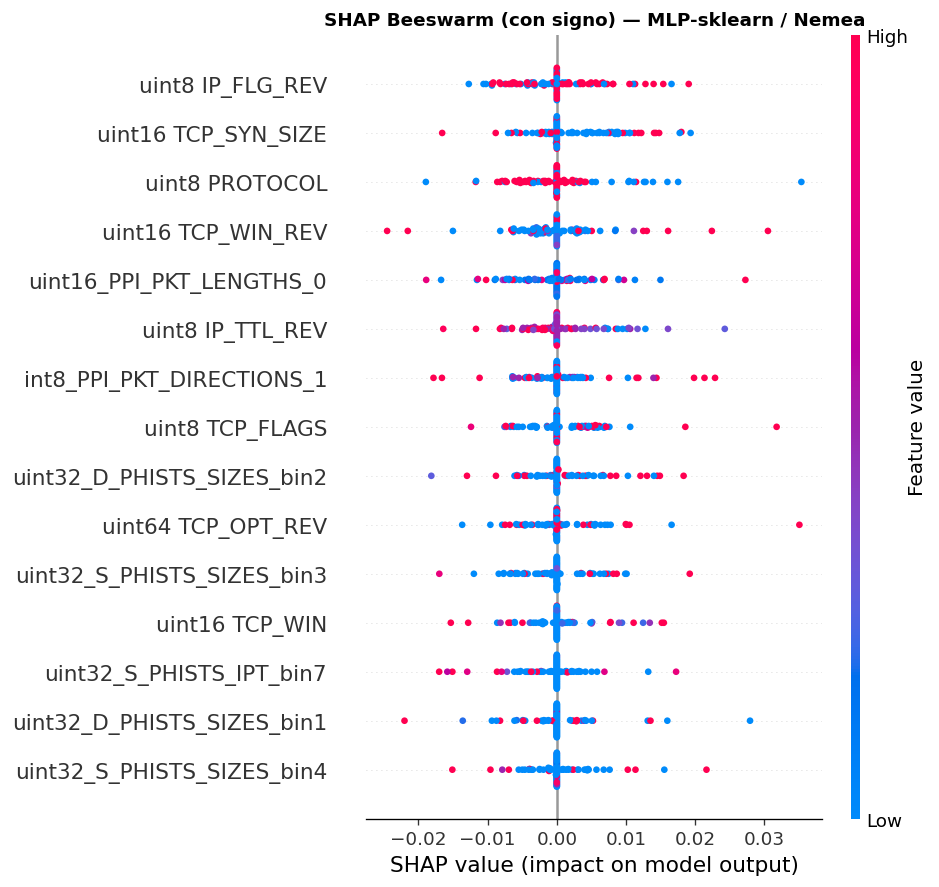

  Top contrafácticos (SHAP medio negativo):
    uint32_D_PHISTS_SIZES_bin0                -0.00142
    uint8 IP_TTL                              -0.00119
    uint8 TCP_FLAGS_REV                       -0.00100
    uint32_D_PHISTS_SIZES_bin4                -0.00087
    sum_D_PHISTS_IPT                          -0.00087

[Tstat] Beeswarm con signo — MLP-sklearn
  Rango SHAP: [-0.0365, 0.0446]
  Features con valores negativos: 35 de 96


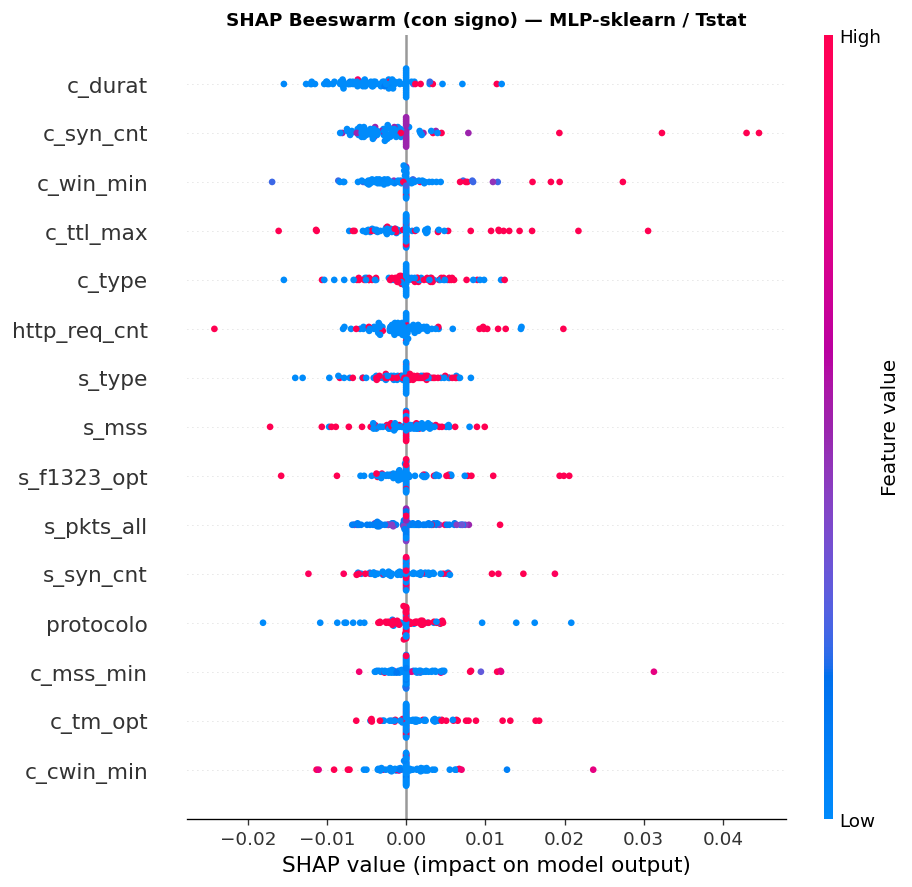

  Top contrafácticos (SHAP medio negativo):
    c_durat                                   -0.00365
    c_syn_cnt                                 -0.00090
    c_rst_cnt                                 -0.00064
    s_sack_cnt                                -0.00062
    c_mss                                     -0.00057

[Tshark] Beeswarm con signo — MLP-sklearn
  Rango SHAP: [-0.0333, 0.0268]
  Features con valores negativos: 20 de 50


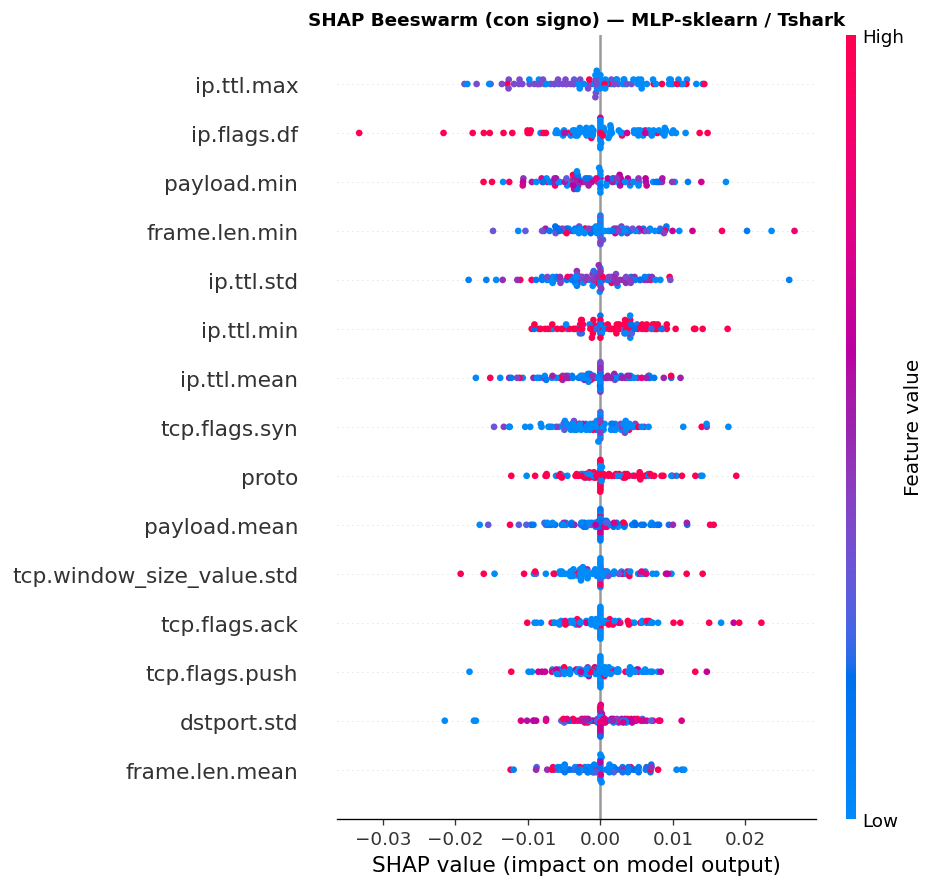

  Top contrafácticos (SHAP medio negativo):
    tcp.flags.reset                           -0.00127
    ip.ttl.mean                               -0.00121
    ip.ttl.std                                -0.00092
    ip.ttl.max                                -0.00092
    payload.min                               -0.00092

[CIC] Beeswarm con signo — MLP-Keras
  Rango SHAP: [-0.0264, 0.0354]
  Features con valores negativos: 29 de 69


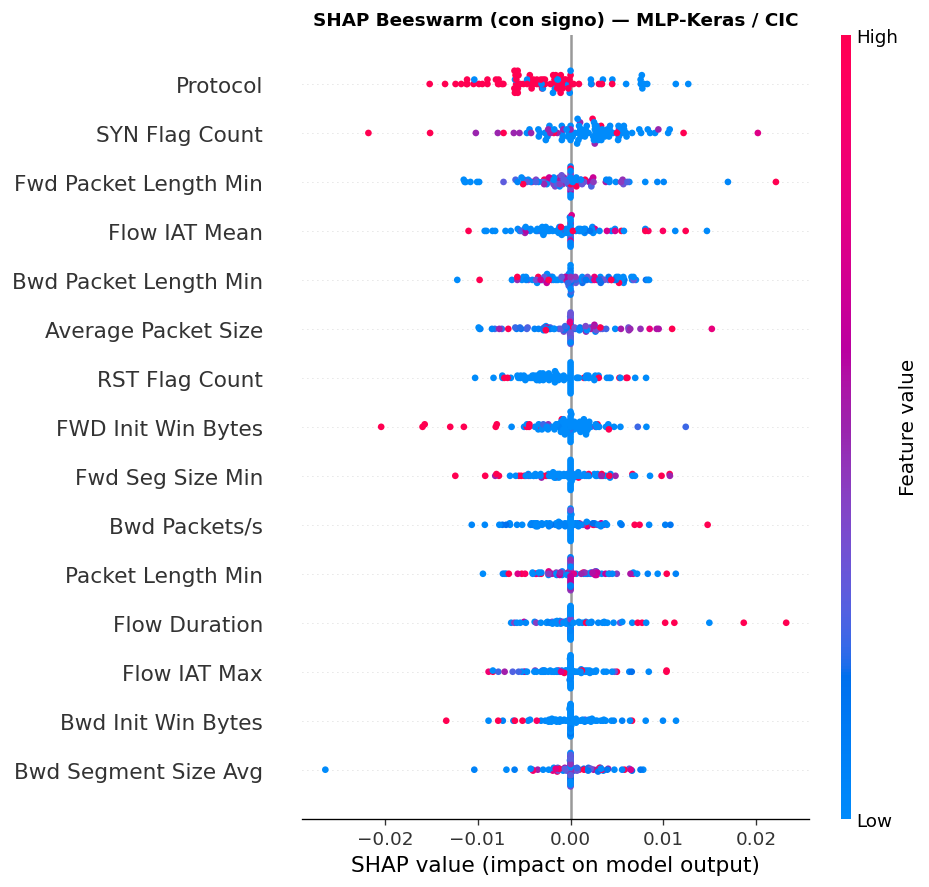

  Top contrafácticos (SHAP medio negativo):
    Protocol                                  -0.00260
    RST Flag Count                            -0.00128
    Idle Mean                                 -0.00083
    FWD Init Win Bytes                        -0.00078
    Packet Length Mean                        -0.00042

[Nemea] Beeswarm con signo — MLP-Keras
  Rango SHAP: [-0.0214, 0.0362]
  Features con valores negativos: 86 de 148


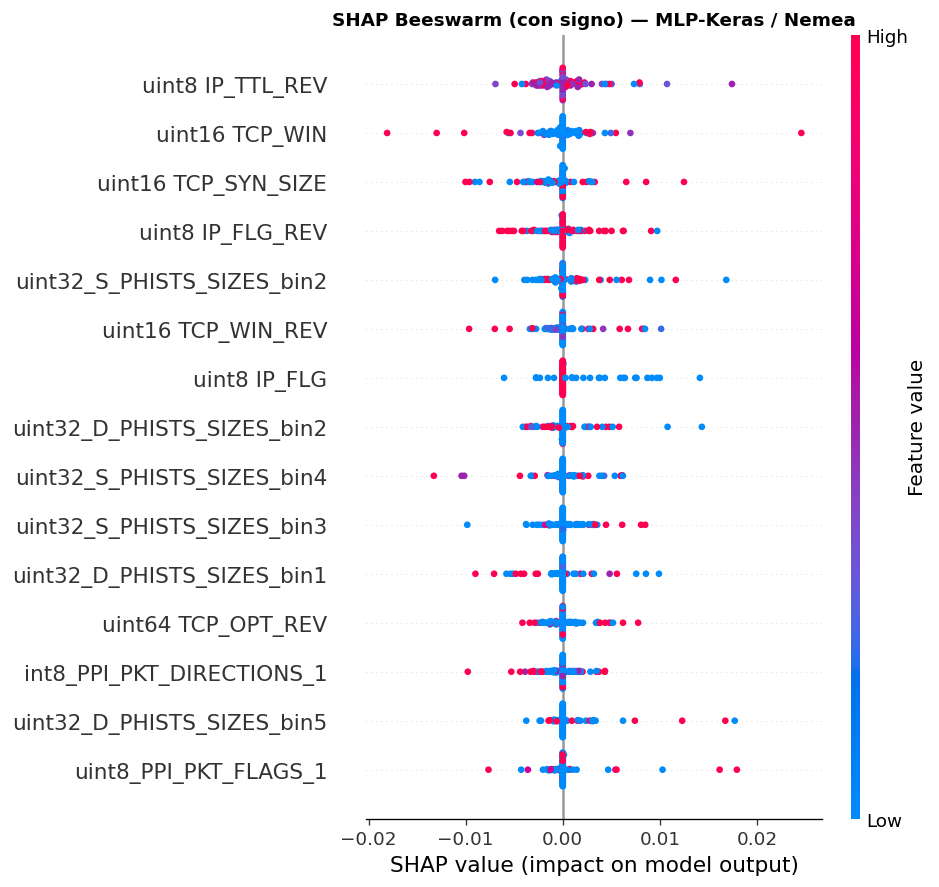

  Top contrafácticos (SHAP medio negativo):
    uint16 TCP_SYN_SIZE                       -0.00070
    uint16_PPI_PKT_LENGTHS_1                  -0.00039
    uint32 TCP_MSS_REV                        -0.00036
    uint32_D_PHISTS_SIZES_bin7                -0.00035
    uint8_PPI_PKT_FLAGS_8                     -0.00030

[Tstat] Beeswarm con signo — MLP-Keras
  Rango SHAP: [-0.0222, 0.0243]
  Features con valores negativos: 42 de 96


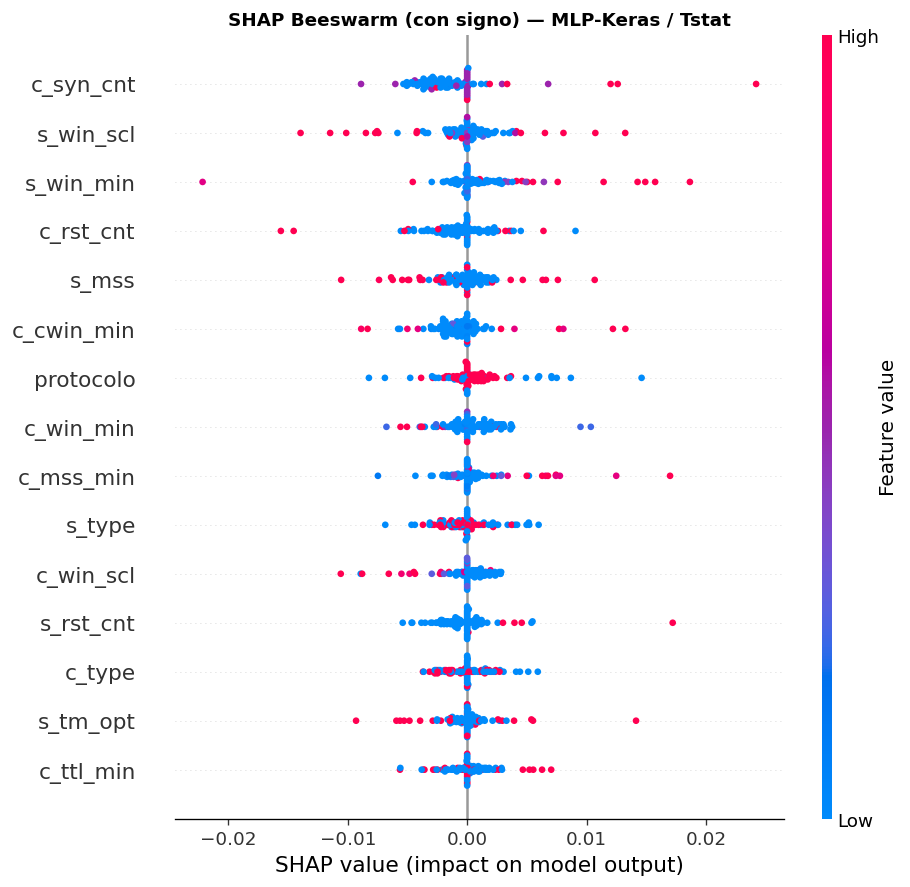

  Top contrafácticos (SHAP medio negativo):
    c_syn_cnt                                 -0.00124
    c_rst_cnt                                 -0.00075
    c_cwin_min                                -0.00060
    s_mss_min                                 -0.00058
    c_fin_cnt                                 -0.00039

[Tshark] Beeswarm con signo — MLP-Keras
  Rango SHAP: [-0.0202, 0.0204]
  Features con valores negativos: 28 de 50


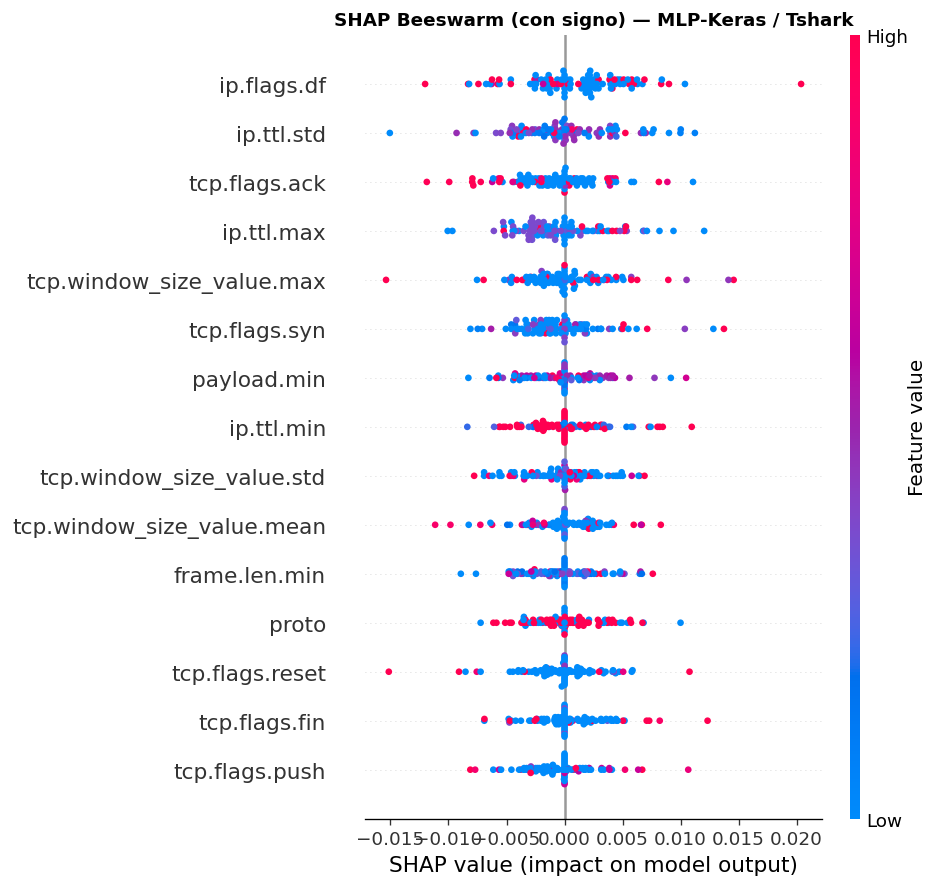

  Top contrafácticos (SHAP medio negativo):
    tcp.flags.ack                             -0.00078
    tcp.flags.push                            -0.00049
    tcp.flags.syn                             -0.00034
    ip.ttl.max                                -0.00031
    frame.len.min                             -0.00027


In [8]:
# ============================================================
# CELDA 7 — BEESWARM CON SIGNO (contrafácticos) — MLP
# Igual que en árboles pero adaptado a KernelExplainer
# ============================================================

def beeswarm_con_signo_mlp(resultados, nombre_modelo):
    for res in resultados:
        herramienta = res['herramienta']
        shap_values = res.get('shap_values_raw')
        X_shap      = res.get('X_shap_raw')
        feature_names = res.get('feature_names')

        if shap_values is None:
            print(f'[{herramienta}] Sin shap_values_raw — saltando beeswarm.')
            continue

        # KernelExplainer devuelve lista de arrays (una por clase) o array 3D
        # Promediamos sobre clases SIN valor absoluto para conservar el signo
        if isinstance(shap_values, list):
            sv_signed = np.mean(np.stack(shap_values, axis=0), axis=0)  # (n_muestras, n_features)
        elif shap_values.ndim == 3:
            sv_signed = shap_values.mean(axis=2)                         # (n_muestras, n_features)
        else:
            sv_signed = shap_values

        print(f'\n[{herramienta}] Beeswarm con signo — {nombre_modelo}')
        print(f'  Rango SHAP: [{sv_signed.min():.4f}, {sv_signed.max():.4f}]')
        print(f'  Features con valores negativos: '
              f'{(sv_signed.mean(axis=0) < 0).sum()} de {sv_signed.shape[1]}')

        fig, ax = plt.subplots(figsize=(9, 7))
        shap.summary_plot(
            sv_signed,
            X_shap,
            feature_names=feature_names,
            max_display=TOP_N,
            plot_type='dot',
            show=False,
            color_bar=True,
        )
        plt.title(f'SHAP Beeswarm (con signo) — {nombre_modelo} / {herramienta}',
                  fontsize=11, fontweight='bold')
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'SHAP_beeswarm_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

        # Resumen contrafácticos
        sv_mean = sv_signed.mean(axis=0)
        negativos = pd.Series(sv_mean, index=feature_names)
        negativos = negativos[negativos < 0].sort_values()
        if len(negativos):
            print(f'  Top contrafácticos (SHAP medio negativo):')
            for feat, val in negativos.head(5).items():
                print(f'    {feat:40s}  {val:.5f}')
        else:
            print(f'  No hay features con SHAP medio negativo.')


beeswarm_con_signo_mlp(resultados_mlpsk, 'MLP-sklearn')
beeswarm_con_signo_mlp(resultados_keras, 'MLP-Keras')


  COMPARACIÓN SHAP MLP-sklearn vs MLP-Keras

  [CIC]
  Spearman SHAP sklearn–Keras: ρ=0.878  (p=4.24e-23)
  Features comunes: 69
  Rank  Feature MLP-sklearn                  Feature MLP-Keras                  
  ----  -----------------------------------  -----------------------------------
     1  SYN Flag Count                       SYN Flag Count                       ✓
     2  Fwd Packet Length Min                Bwd Packet Length Min                 
     3  Bwd Packets/s                        FWD Init Win Bytes                    
     4  Bwd Packet Length Min                Protocol                              
     5  Protocol                             Bwd Packets/s                         
     6  Packet Length Min                    Fwd Packet Length Min                 
     7  FWD Init Win Bytes                   Fwd Seg Size Min                      
     8  Fwd Seg Size Min                     Average Packet Size                   
     9  Fwd IAT Max                 

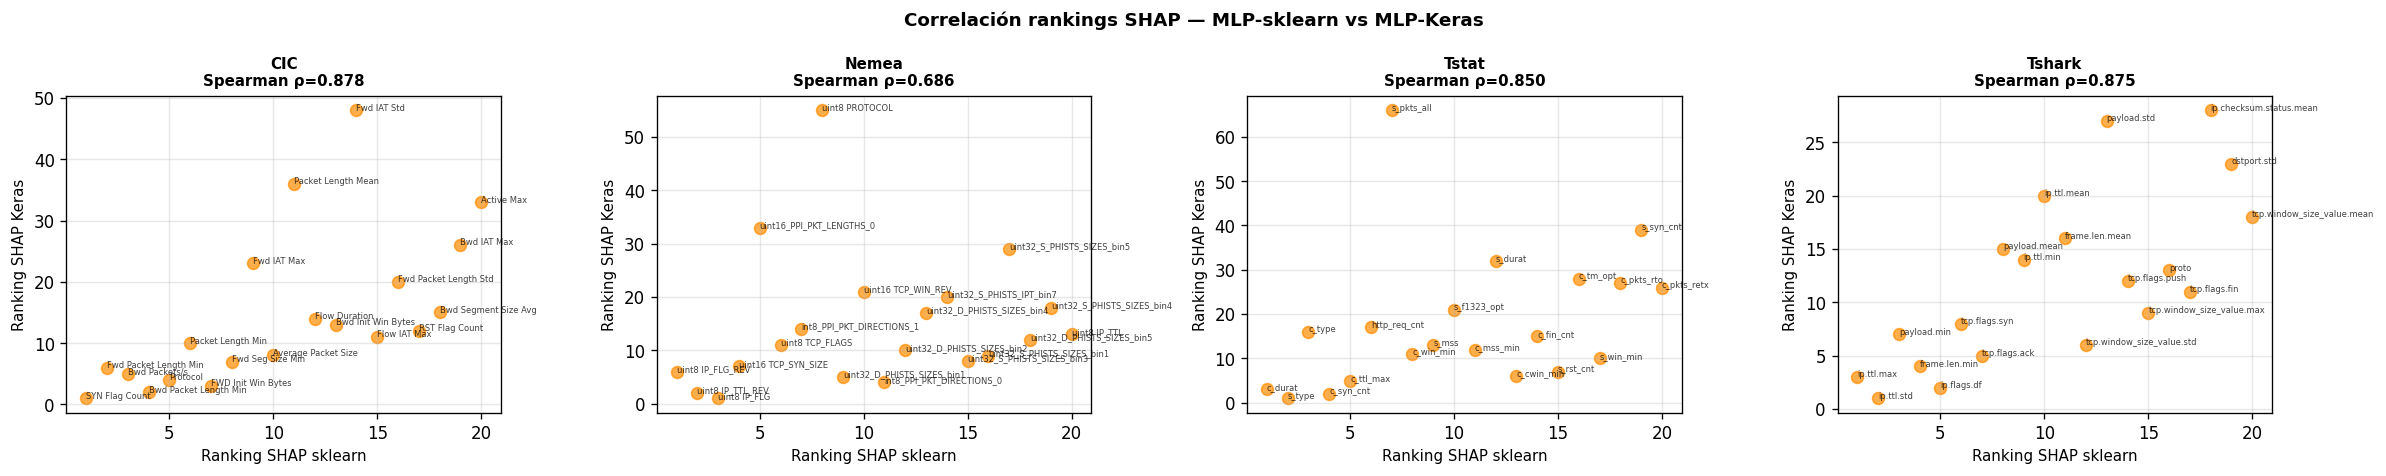

In [9]:
# ============================================================
# CELDA 8 — COMPARACIÓN SHAP ENTRE HERRAMIENTAS — MLP
# Nota: MLP no tiene MDI, por eso comparamos solo rankings SHAP
# entre modelos (sklearn vs Keras) por herramienta
# ============================================================

def comparar_shap_mlp(resultados_sk, resultados_keras):
    print(f'\n{"="*65}')
    print(f'  COMPARACIÓN SHAP MLP-sklearn vs MLP-Keras')
    print(f'{"="*65}')

    fig_scatter, axes = plt.subplots(1, len(HERRAMIENTAS), figsize=(5 * len(HERRAMIENTAS), 4))

    for ax, herramienta in zip(axes, HERRAMIENTAS):
        res_sk = next((r for r in resultados_sk if r['herramienta'] == herramienta), None)
        res_ke = next((r for r in resultados_keras if r['herramienta'] == herramienta), None)

        if res_sk is None or res_ke is None:
            ax.set_visible(False)
            continue

        feature_names_sk = res_sk.get('feature_names', [])
        feature_names_ke = res_ke.get('feature_names', [])
        features_comunes = [f for f in feature_names_sk if f in feature_names_ke]

        if not features_comunes:
            ax.set_visible(False)
            continue

        # Reconstruir importancia SHAP completa para features comunes
        def shap_serie(res, feature_names, features_comunes):
            sv = res.get('shap_values_raw')
            if sv is None:
                return pd.Series(dtype=float)
            if isinstance(sv, list):
                shap_abs = np.mean([np.abs(s) for s in sv], axis=0)
            elif sv.ndim == 3:
                shap_abs = np.mean(np.abs(sv), axis=2)
            else:
                shap_abs = np.abs(sv)
            serie = pd.Series(shap_abs.mean(axis=0), index=feature_names)
            return serie.reindex(features_comunes).fillna(0)

        serie_sk = shap_serie(res_sk, feature_names_sk, features_comunes)
        serie_ke = shap_serie(res_ke, feature_names_ke, features_comunes)

        rk_sk = serie_sk.rank(ascending=False)
        rk_ke = serie_ke.rank(ascending=False)
        corr, pval = stats.spearmanr(rk_sk, rk_ke)

        print(f'\n  [{herramienta}]')
        print(f'  Spearman SHAP sklearn–Keras: ρ={corr:.3f}  (p={pval:.2e})')
        print(f'  Features comunes: {len(features_comunes)}')

        # Tabla top-10
        top10_sk  = serie_sk.nlargest(10)
        top10_ke  = serie_ke.nlargest(10)
        print(f'  {"Rank":>4}  {"Feature MLP-sklearn":35s}  {"Feature MLP-Keras":35s}')
        print(f'  {"-"*4}  {"-"*35}  {"-"*35}')
        for i in range(10):
            f_sk = top10_sk.index[i] if i < len(top10_sk) else ''
            f_ke = top10_ke.index[i] if i < len(top10_ke) else ''
            marca = '✓' if f_sk == f_ke else ' '
            print(f'  {i+1:>4}  {f_sk:35s}  {f_ke:35s}  {marca}')

        c5  = len(set(top10_sk.index[:5]) & set(top10_ke.index[:5]))
        c10 = len(set(top10_sk.index[:10]) & set(top10_ke.index[:10]))
        print(f'  Coincidencia top-5:  {c5}/5')
        print(f'  Coincidencia top-10: {c10}/10')

        # Scatter
        top20 = serie_sk.nlargest(20).index
        ax.scatter(rk_sk[top20], rk_ke[top20], alpha=0.7, s=50, color='darkorange')
        for feat in top20:
            ax.annotate(feat, (rk_sk[feat], rk_ke[feat]), fontsize=5, alpha=0.75)
        ax.set_xlabel('Ranking SHAP sklearn', fontsize=9)
        ax.set_ylabel('Ranking SHAP Keras', fontsize=9)
        ax.set_title(f'{herramienta}\nSpearman ρ={corr:.3f}', fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)

    fig_scatter.suptitle('Correlación rankings SHAP — MLP-sklearn vs MLP-Keras',
                         fontsize=11, fontweight='bold')
    plt.tight_layout()
    if GUARDAR_FIGURAS:
        fig_scatter.savefig(RUTA_FIGURAS / 'SHAP_correlacion_MLP_sklearn_vs_keras.pdf', dpi=150)
    plt.show()
    plt.close()


comparar_shap_mlp(resultados_mlpsk, resultados_keras)